In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

df = pd.read_csv('data/data.csv')
df.head(5)

,sno,age,gender,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,male,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,yes
1,1,37,male,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,yes
2,2,41,female,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,yes
3,3,56,male,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,yes
4,4,57,female,0,NaN,354.0,0,1,163.0,1,0.6,2,0,2,yes


In [2]:
df['gender']=pd.factorize(df['gender'])[0]
df.isna().sum()

sno         0
age         0
gender      0
cp          0
trestbps    4
chol        1
fbs         0
restecg     0
thalach     5
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [3]:
cleaned_df=df.dropna()
cleaned_df.shape[0]

293

In [4]:
x = cleaned_df.drop(columns=["target","sno"], axis=1)
y = cleaned_df["target"]

np.random.seed(42)

# Split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [5]:
from sklearn.model_selection import RandomizedSearchCV

log_reg_grid = {"C": np.logspace(-4, 4, 20),
                "solver": ["liblinear"]}

rs_log_reg = RandomizedSearchCV(LogisticRegression(),
                                param_distributions=log_reg_grid,
                                cv=5,
                                n_iter=20,
                                verbose=True)
rs_log_reg.fit(x_train, y_train)
rs_log_reg.best_params_

Fitting 5 folds for each of 20 candidates, totalling 100 fits


{'solver': 'liblinear', 'C': 0.08858667904100823}

In [6]:
rs_log_reg.score(x_test, y_test)

0.7966101694915254

In [7]:
x_test.iloc[0]

age          46.0
gender        0.0
cp            1.0
trestbps    101.0
chol        197.0
fbs           1.0
restecg       1.0
thalach     156.0
exang         0.0
oldpeak       0.0
slope         2.0
ca            0.0
thal          3.0
Name: 87, dtype: float64

In [8]:
rs_log_reg.predict(x_test.iloc[[0]])

array(['yes'], dtype=object)

### Save Artifacts

In [9]:
import os, joblib

ARTIFACTS_DIR = "artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

MODEL_PATH = os.path.join(ARTIFACTS_DIR, "model.pkl")
best_model = rs_log_reg.best_estimator_
joblib.dump(best_model, MODEL_PATH)
FEATURES_PATH = os.path.join(ARTIFACTS_DIR, "features.pkl")
joblib.dump(list(x_train.columns), FEATURES_PATH)

os.listdir('artifacts')

['model.pkl', 'features.pkl']

In [10]:

model = joblib.load("artifacts/model.pkl")
features = joblib.load("artifacts/features.pkl")

print("Loaded features:", features)

input_data = {
    "age": 46.0,
    "gender": 0,
    "cp": 1,
    "trestbps": 101.0,
    "chol": 197.0,
    "fbs": 1,
    "restecg": 1,
    "thalach": 156.0,
    "exang": 0,
    "oldpeak": 0.0,
    "slope": 2,
    "ca": 0,
    "thal": 3
}

X_new = pd.DataFrame(
    [[input_data[col] for col in features]],
    columns=features
)

y_pred = model.predict(X_new)
y_prob = model.predict_proba(X_new)

print("Predicted class:", y_pred[0])
print("Class probabilities:", y_prob[0])

Loaded features: ['age', 'gender', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Predicted class: yes
Class probabilities: [0.14873858 0.85126142]


# Explainability

In [11]:
!pip install shap -q
import shap

/var/tmp/ipykernel_55664/2925905719.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[neg_idx], x_test.iloc[neg_idx])


ValueError: zero-size array to reduction operation minimum which has no identity

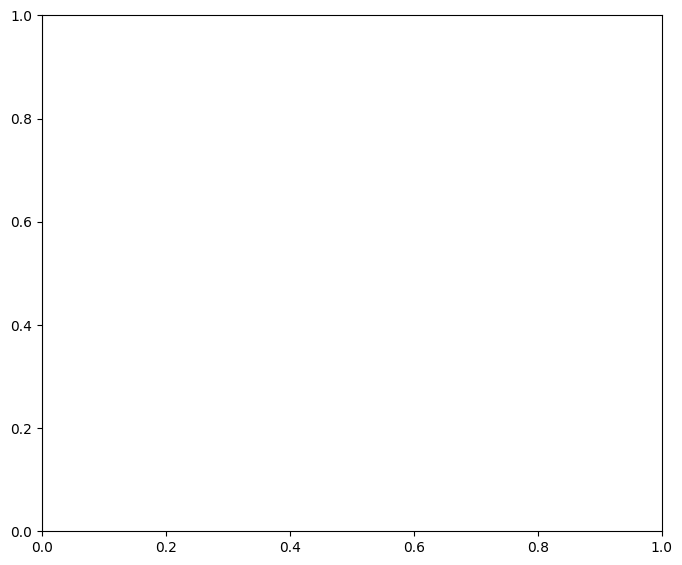

In [12]:
explainer = shap.LinearExplainer(best_model, x_train)
shap_values = explainer.shap_values(x_test)

# Select samples predicted as 0
neg_idx = best_model.predict(x_test) == 0
shap.summary_plot(shap_values[neg_idx], x_test.iloc[neg_idx])

# Fairness

In [ ]:
! pip install fairlearn -q

from fairlearn.metrics import MetricFrame, selection_rate
import pandas as pd

age_bins = pd.cut(x_test["age"], bins=[20,40,60,80])

y_pred = best_model.predict(x_test)

mf = MetricFrame(
    metrics=selection_rate,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=age_bins
)

mf.by_group


# Per-sample
## prediction + logging + observability

# Performance monitoring

In [ ]:
! wrk -t12 -c2000 -d30s http://<EXTERNAL-IP>/predict


# Input Drift Detection

In [ ]:
from scipy.stats import ks_2samp

drift_results = {}

for col in x_train.columns:
    stat, p = ks_2samp(x_train[col], random_data[col])
    drift_results[col] = p < 0.05

drift_results
